# Used Car Price Prediction — EDA, Data Cleaning & Feature Engineering

**Dataset:** [Used Car Price Prediction Dataset](https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset) (Kaggle)

**Goal:** Explore the raw dataset, identify data quality issues, clean it, and engineer features useful for a future ML model predicting used car prices.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option('display.max_columns', None)
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('used_cars.csv')
df.shape

(4009, 12)

---
# Part 1: Exploratory Data Analysis (EDA)

## 1.1 Dataset Structure

In [2]:
df.head(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [3]:
df.dtypes

brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

**Numerical features (as loaded):** `model_year` — the only column that loads as truly numeric.

**Categorical / object features:** `brand`, `model`, `fuel_type`, `engine`, `transmission`, `ext_col`, `int_col`, `accident`, `clean_title`.

**Numeric-looking but stored as text (need cleaning):** `milage` (e.g. `"51,000 mi."`) and `price` (e.g. `"$10,300"`) are both stored as strings with units/currency symbols and thousands separators, so they must be parsed into real numeric columns before any statistical analysis or modeling.

## 1.2 Descriptive Statistics

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,4009,57,Ford,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,4009,1898,M3 Base,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,4009.0,NaN,NaN,NaN,2015.51559,6.104816,1974.0,2012.0,2017.0,2020.0,2024.0
milage,4009,2818,"110,000 mi.",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,3839,7,Gasoline,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,4009,1146,2.0L I4 16V GDI DOHC Turbo,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4009,62,A/T,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,4009,319,Black,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,4009,156,Black,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident,3896,2,None reported,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.3 Missing Values

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
clean_title,596,14.87
fuel_type,170,4.24
accident,113,2.82


- `clean_title` is missing for **14.87%** of rows.
- `fuel_type` is missing for **4.24%** of rows.
- `accident` is missing for **2.82%** of rows.

`model_year`, `milage`, `price`, `brand`, `model`, `transmission`, `ext_col`, and `int_col` have no missing values.

## 1.4 Duplicate Records

In [6]:
print("Exact duplicate rows:", df.duplicated().sum())

Exact duplicate rows: 0


No exact duplicate rows were found in this dataset.

## 1.5 Unique Values in Categorical Features

In [7]:
cat_cols = ['brand', 'fuel_type', 'transmission', 'accident', 'clean_title']
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

brand: 57 unique values
fuel_type: 7 unique values
transmission: 62 unique values
accident: 2 unique values
clean_title: 1 unique values


In [8]:
print("clean_title values:", df['clean_title'].unique())
print()
print("accident values:", df['accident'].unique())
print()
print("fuel_type values:", df['fuel_type'].unique())

clean_title values: <StringArray>
['Yes', nan]
Length: 2, dtype: str

accident values: <StringArray>
['At least 1 accident or damage reported', 'None reported', nan]
Length: 3, dtype: str

fuel_type values: <StringArray>
[ 'E85 Flex Fuel',       'Gasoline',         'Hybrid',              nan,
         'Diesel', 'Plug-In Hybrid',              '–',  'not supported']
Length: 8, dtype: str


A few things stand out:
- `clean_title` only ever takes the value **`"Yes"`** or is missing — there is no `"No"` value. This strongly suggests that missing here means the title status wasn't reported as clean (not that it's genuinely unknown), which matters for how we handle it during cleaning.
- `fuel_type` contains two junk values that are not real fuel types: **`"–"`** (a dash) and **`"not supported"`**. These should be treated as missing data, not as legitimate categories.
- `accident` is a clean binary: `"At least 1 accident or damage reported"` vs `"None reported"`, plus missing values.

In [9]:
print("transmission sample of unique values (first 20 of", df['transmission'].nunique(), "):")
print(df['transmission'].unique()[:20])

transmission sample of unique values (first 20 of 62 ):
<StringArray>
[                      '6-Speed A/T',                 '8-Speed Automatic',
                         'Automatic',                       '7-Speed A/T',
                                 'F',                               'A/T',
                       '8-Speed A/T',    'Transmission w/Dual Shift Mode',
                 '9-Speed Automatic',                       '6-Speed M/T',
                      '10-Speed A/T',                       '9-Speed A/T',
                       '5-Speed A/T',                       '1-Speed A/T',
                     'Automatic CVT', '7-Speed Automatic with Auto-Shift',
                             'CVT-F',                               'M/T',
 '6-Speed Automatic with Auto-Shift',                '10-Speed Automatic']
Length: 20, dtype: str


`transmission` has 62 unique values with inconsistent formatting — e.g. `'A/T'`, `'6-Speed A/T'`, `'Automatic'`, and `'8-Speed Automatic'` all describe automatic transmissions but are recorded as different strings. This is a real data-quality issue worth normalizing during feature engineering.

## 1.6 Cleaning Numeric Columns for Analysis

Before we can analyze distributions or outliers in `milage` and `price`, we parse them into real numeric types.

In [10]:
df['milage_numeric'] = (
    df['milage'].str.replace(' mi.', '', regex=False)
                .str.replace(',', '', regex=False)
                .astype(float)
)

df['price_numeric'] = (
    df['price'].str.replace('$', '', regex=False)
               .str.replace(',', '', regex=False)
               .astype(float)
)

df[['milage', 'milage_numeric', 'price', 'price_numeric']].head()

,milage,milage_numeric,price,price_numeric
0,"51,000 mi.",51000.0,"$10,300",10300.0
1,"34,742 mi.",34742.0,"$38,005",38005.0
2,"22,372 mi.",22372.0,"$54,598",54598.0
3,"88,900 mi.",88900.0,"$15,500",15500.0
4,"9,835 mi.",9835.0,"$34,999",34999.0


## 1.7 Distributions & Outlier Detection

In [11]:
df[['model_year', 'milage_numeric', 'price_numeric']].describe()

,model_year,milage_numeric,price_numeric
count,4009.000000,4009.000000,4.009000e+03
mean,2015.515590,64717.551010,4.455319e+04
std,6.104816,52296.599459,7.871064e+04
min,1974.000000,100.000000,2.000000e+03
25%,2012.000000,23044.000000,1.720000e+04
50%,2017.000000,52775.000000,3.100000e+04
75%,2020.000000,94100.000000,4.999000e+04
max,2024.000000,405000.000000,2.954083e+06


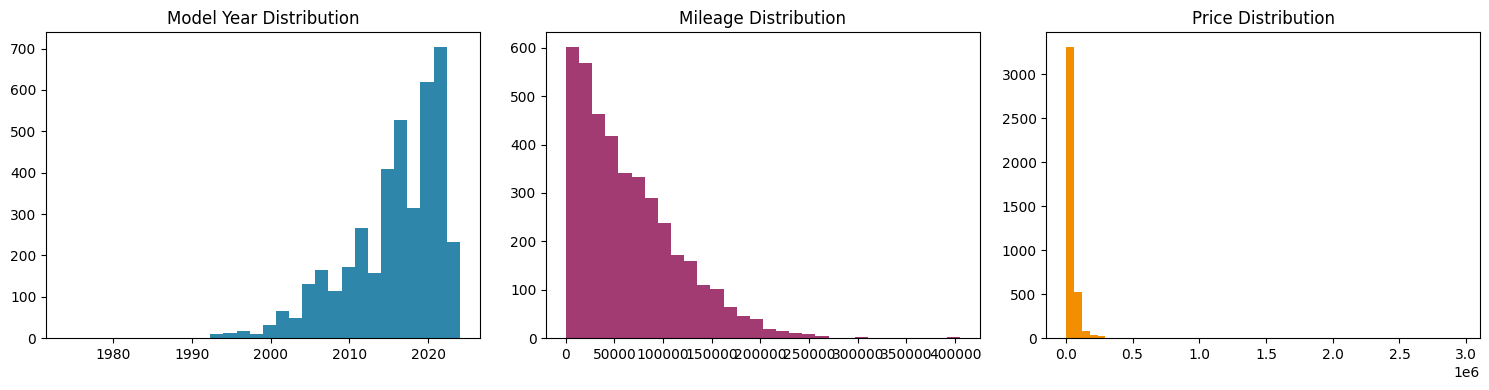

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].hist(df['model_year'], bins=30, color='#2E86AB')
axes[0].set_title('Model Year Distribution')
axes[1].hist(df['milage_numeric'], bins=30, color='#A23B72')
axes[1].set_title('Mileage Distribution')
axes[2].hist(df['price_numeric'], bins=50, color='#F18F01')
axes[2].set_title('Price Distribution')
plt.tight_layout()
plt.show()

The price distribution is heavily right-skewed — most cars are priced well under $100,000, but a small number of extreme outliers stretch the axis dramatically.

In [13]:
top_price = df.nlargest(5, 'price_numeric')[['brand', 'model', 'model_year', 'price_numeric']]
top_price

,brand,model,model_year,price_numeric
693,Maserati,Quattroporte Base,2005,2954083.0
229,Bugatti,Veyron 16.4 Grand Sport,2011,1950995.0
3046,Porsche,Carrera GT Base,2005,1599000.0
1356,Lamborghini,Aventador SVJ Base,2021,749950.0
624,Rolls-Royce,Cullinan,2022,695000.0


Investigating the top 5 most expensive listings shows two different situations:

- **Genuine exotic/luxury cars**: the Bugatti Veyron 16.4 Grand Sport (~$1.95M), Porsche Carrera GT (~$1.6M), Lamborghini Aventador SVJ (~$750K), and Rolls-Royce Cullinan (~$695K) are all real ultra-high-end vehicles that legitimately sell in this price range, even used.
- **A likely data entry error**: the top listing, a **2005 Maserati Quattroporte Base priced at $2,954,083**, is almost certainly incorrect — a base Quattroporte does not sell anywhere near this price even new. This looks like a data entry mistake (e.g. an extra digit) rather than a real listing.

This distinction matters: not every extreme value should be treated the same way during cleaning.

In [14]:
top_mileage = df.nlargest(5, 'milage_numeric')[['brand', 'model', 'model_year', 'milage_numeric']]
top_mileage

,brand,model,model_year,milage_numeric
2764,Honda,Accord Sport,2013,405000.0
3348,Mercedes-Benz,Sprinter 2500,2016,399000.0
2175,Ford,Excursion Limited,2001,333361.0
3757,Ford,F-250 XL Crew Cab Super Duty,2004,315000.0
31,Dodge,Ram 1500 Laramie Mega Cab,2006,300183.0


Mileage outliers (300,000-405,000 miles) look plausible for very old, high-use vehicles and don't show the same signs of data entry error as the Maserati price does.

## 1.8 Key Insights (EDA)

**Insight 1 — Price is extremely right-skewed, with at least one likely data-entry error.** The median price is ~\$31,000 but the mean is ~\$44,553 (heavily pulled up by outliers), and the single highest listing (\$2.95M for a base Maserati Quattroporte) is implausible and should be corrected or removed rather than treated as a genuine luxury outlier like the Bugatti or Porsche listings nearby it.

**Insight 2 — `clean_title` missingness likely encodes information, not randomness.** Since `clean_title` only ever contains `"Yes"` or is blank (never `"No"`), the ~15% missing values probably represent cars *without* a clean title, rather than data that's simply unrecorded. Imputing this column with a placeholder like "Unknown" would discard a real, useful signal for price prediction.

**Insight 3 — `fuel_type` has two junk categories that are actually missing data in disguise.** The values `"–"` and `"not supported"` are not real fuel types; treating them as missing (alongside the true NaNs) is more accurate than treating them as their own category, and prevents an ML model from learning nonsense from these labels.

**Insight 4 — `transmission` suffers from severe category fragmentation.** With 62 unique values, many representing the same underlying transmission type in different text formats (e.g. `'A/T'`, `'6-Speed A/T'`, `'Automatic'`), this column needs normalization into a small number of true categories (Automatic / Manual / CVT / Other) before it's usable in a model — otherwise a model would treat near-identical transmissions as unrelated categories.

**Insight 5 — The `engine` column bundles multiple numeric features into unstructured text.** Horsepower, displacement (in liters), and cylinder count are all embedded in free-text strings like `"300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability"`. These can be extracted into separate numeric columns (successfully parsed for ~80%+ of rows), turning previously unusable text into strong candidate predictors for price.

---
# Part 2: Data Cleaning & Feature Engineering

## 2.1 Handling Missing Values

In [15]:
df_clean = df.drop(columns=['milage_numeric', 'price_numeric']).copy()

# fuel_type: treat junk categories as missing, then impute as 'Unknown'
df_clean['fuel_type'] = df_clean['fuel_type'].replace({'–': np.nan, 'not supported': np.nan})
df_clean['fuel_type'] = df_clean['fuel_type'].fillna('Unknown')

# clean_title: missing almost certainly means "not a clean title" — fill with 'No'
df_clean['clean_title'] = df_clean['clean_title'].fillna('No')

# accident: missing likely means unreported — treat as its own category rather than guessing
df_clean['accident'] = df_clean['accident'].fillna('Unknown')

print(df_clean[['fuel_type', 'clean_title', 'accident']].isnull().sum())

fuel_type      0
clean_title    0
accident       0
dtype: int64


**Reasoning:**
- `fuel_type`: junk values (`"–"`, `"not supported"`) were first converted to missing, then filled with `"Unknown"` since dropping ~4% of rows loses data unnecessarily and the missingness may itself be informative (e.g. rare fuel types not catalogued properly).
- `clean_title`: since the column never contains an explicit `"No"`, missing values are recoded to `"No"` — this preserves the real signal (a non-clean title likely affects price) rather than treating it as unknown.
- `accident`: filled with `"Unknown"` rather than assuming either outcome, since there's no strong basis to assume "no accident" by default.

## 2.2 Removing Duplicate Records

In [16]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Rows before: {before}, after: {after}, removed: {before - after}")

Rows before: 4009, after: 4009, removed: 0


No exact duplicates were present, so no rows were removed at this step — this is a defensive step to keep in the pipeline in case future data batches contain duplicates.

## 2.3 Correcting Data Types

In [17]:
df_clean['milage'] = (
    df_clean['milage'].str.replace(' mi.', '', regex=False)
                       .str.replace(',', '', regex=False)
                       .astype(float)
)

df_clean['price'] = (
    df_clean['price'].str.replace('$', '', regex=False)
                      .str.replace(',', '', regex=False)
                      .astype(float)
)

df_clean[['milage', 'price']].dtypes

milage    float64
price     float64
dtype: object

`milage` and `price` are now proper numeric (float) columns instead of text with embedded units/currency symbols.

## 2.4 Handling Outliers

In [18]:
print("Price before outlier handling:")
print(df_clean['price'].describe())
print()

# The Maserati Quattroporte listing is a clear data-entry error (base model at ~$3M is implausible)
# Rather than deleting the row (losing brand/model/feature data), cap it using a business-informed rule:
# flag anything above a reasonable luxury-market ceiling for review, and cap extreme values using
# the 99th percentile (winsorizing) to reduce distortion while keeping legitimate exotic-car prices.

price_cap = df_clean['price'].quantile(0.99)
print(f"99th percentile price cap: ${price_cap:,.2f}")

n_capped = (df_clean['price'] > price_cap).sum()
print(f"Rows above cap: {n_capped}")

df_clean['price_capped'] = df_clean['price'].clip(upper=price_cap)
df_clean[['brand', 'model', 'price', 'price_capped']].nlargest(5, 'price')

Price before outlier handling:
count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

99th percentile price cap: $272,713.28
Rows above cap: 41


,brand,model,price,price_capped
693,Maserati,Quattroporte Base,2954083.0,272713.28
229,Bugatti,Veyron 16.4 Grand Sport,1950995.0,272713.28
3046,Porsche,Carrera GT Base,1599000.0,272713.28
1356,Lamborghini,Aventador SVJ Base,749950.0,272713.28
624,Rolls-Royce,Cullinan,695000.0,272713.28


**Approach taken:** rather than deleting outlier rows outright (which would throw away otherwise-valid brand/model/feature data) or leaving the implausible \$2.95M Maserati entry untouched, we cap (winsorize) prices at the 99th percentile into a new `price_capped` column. This keeps genuinely expensive exotic cars (Bugatti, Porsche, Lamborghini) largely intact while preventing the one clear data-entry error from distorting summary statistics or model training. The original `price` column is preserved unchanged for transparency; `price_capped` is the column intended for modeling.

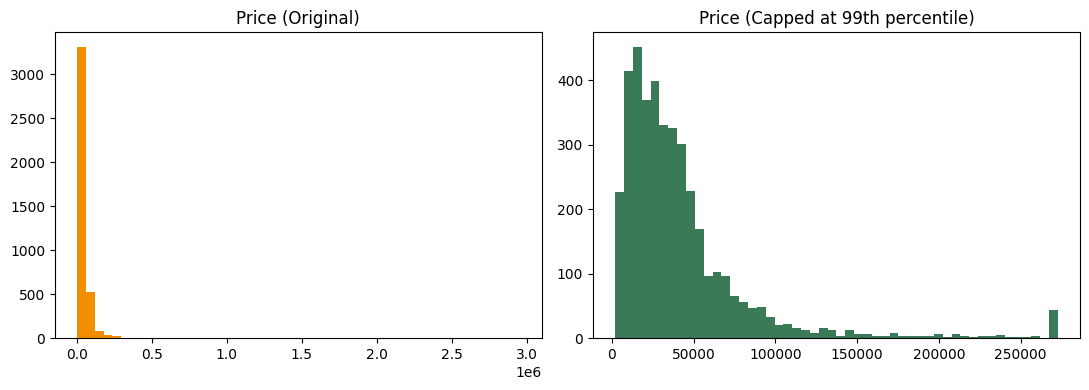

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(df_clean['price'], bins=50, color='#F18F01')
axes[0].set_title('Price (Original)')
axes[1].hist(df_clean['price_capped'], bins=50, color='#3B7A57')
axes[1].set_title('Price (Capped at 99th percentile)')
plt.tight_layout()
plt.show()

## 2.5 Feature Engineering

Five engineered features, each designed to add predictive signal for a future price model.

### Feature 1 — `car_age` (numeric)

Derived from `model_year`; raw model year is less useful to a model than age relative to today, since "age" generalizes across time in a way a specific year does not.

In [20]:
CURRENT_YEAR = 2026
df_clean['car_age'] = CURRENT_YEAR - df_clean['model_year']
df_clean[['model_year', 'car_age']].head()

,model_year,car_age
0,2013,13
1,2021,5
2,2022,4
3,2015,11
4,2021,5


### Feature 2 — `mileage_per_year` (numeric)

Mileage alone doesn't capture usage intensity — a 10-year-old car with 100,000 miles has been driven much less per year than a 2-year-old car with the same mileage. This normalizes mileage by age.

In [21]:
df_clean['mileage_per_year'] = df_clean['milage'] / df_clean['car_age'].replace(0, 1)
df_clean[['milage', 'car_age', 'mileage_per_year']].head()

,milage,car_age,mileage_per_year
0,51000.0,13,3923.076923
1,34742.0,5,6948.400000
2,22372.0,4,5593.000000
3,88900.0,11,8081.818182
4,9835.0,5,1967.000000


### Feature 3, 4, 5 — `horsepower`, `engine_displacement_l`, `num_cylinders` (numeric, extracted from `engine` text)

The raw `engine` column is unstructured text bundling multiple useful numeric attributes. Regex extraction turns it into three clean numeric features.

In [22]:
def extract_hp(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r'([\d.]+)\s*HP', s)
    return float(m.group(1)) if m else np.nan

def extract_displacement(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r'([\d.]+)\s*L\b', s)
    return float(m.group(1)) if m else np.nan

def extract_cylinders(s):
    if pd.isna(s):
        return np.nan
    m = re.search(r'(\d+)\s*Cylinder', s)
    if m:
        return int(m.group(1))
    m2 = re.search(r'V(\d+)', s)
    if m2:
        return int(m2.group(1))
    m3 = re.search(r'I(\d+)', s)
    if m3:
        return int(m3.group(1))
    return np.nan

df_clean['horsepower'] = df_clean['engine'].apply(extract_hp)
df_clean['engine_displacement_l'] = df_clean['engine'].apply(extract_displacement)
df_clean['num_cylinders'] = df_clean['engine'].apply(extract_cylinders)

print("Extraction success rates:")
print("horsepower:", df_clean['horsepower'].notna().sum(), "/", len(df_clean))
print("engine_displacement_l:", df_clean['engine_displacement_l'].notna().sum(), "/", len(df_clean))
print("num_cylinders:", df_clean['num_cylinders'].notna().sum(), "/", len(df_clean))

df_clean[['engine', 'horsepower', 'engine_displacement_l', 'num_cylinders']].head(8)

Extraction success rates:
horsepower: 3201 / 4009
engine_displacement_l: 3634 / 4009
num_cylinders: 3569 / 4009


,engine,horsepower,engine_displacement_l,num_cylinders
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0,3.7,6.0
1,3.8L V6 24V GDI DOHC,NaN,3.8,6.0
2,3.5 Liter DOHC,NaN,NaN,NaN
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0,3.5,6.0
4,2.0L I4 16V GDI DOHC Turbo,NaN,2.0,4.0
5,2.4 Liter,NaN,NaN,NaN
6,292.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,292.0,2.0,4.0
7,282.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,282.0,4.4,8.0


**Note on missing extracted values:** where horsepower, displacement, or cylinder count couldn't be parsed (e.g. purely descriptive engine strings with no numbers, or electric motors described without displacement), the value is left as `NaN` rather than guessed — a future model can use `SimpleImputer` or a "missing" indicator flag at training time, but fabricating a specific number here would introduce false precision.

### Bonus Feature — `transmission_type` (normalized category)

While not one of the five required numeric features, this cleans up the 62-way fragmented `transmission` column into a small number of meaningful categories, directly addressing Insight 4 from the EDA.

In [23]:
def normalize_transmission(t):
    if pd.isna(t):
        return 'Unknown'
    t_lower = t.lower()
    if 'cvt' in t_lower:
        return 'CVT'
    if 'm/t' in t_lower or 'manual' in t_lower:
        return 'Manual'
    if 'a/t' in t_lower or 'automatic' in t_lower:
        return 'Automatic'
    return 'Other'

df_clean['transmission_type'] = df_clean['transmission'].apply(normalize_transmission)
df_clean['transmission_type'].value_counts()

transmission_type
Automatic    3109
Other         426
Manual        374
CVT           100
Name: count, dtype: int64

## 2.6 Final Cleaned Dataset

In [24]:
df_clean.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,price_capped,car_age,mileage_per_year,horsepower,engine_displacement_l,num_cylinders,transmission_type
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300.0,10300.0,13,3923.076923,300.0,3.7,6.0,Automatic
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005.0,38005.0,5,6948.400000,NaN,3.8,6.0,Automatic
2,Lexus,RX 350 RX 350,2022,22372.0,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,No,54598.0,54598.0,4,5593.000000,NaN,NaN,NaN,Automatic
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,15500.0,15500.0,11,8081.818182,354.0,3.5,6.0,Automatic
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,No,34999.0,34999.0,5,1967.000000,NaN,2.0,4.0,Automatic


In [25]:
df_clean.shape

(4009, 19)

In [26]:
df_clean.to_csv('cleaned_used_cars.csv', index=False)
print("Saved cleaned_used_cars.csv")

Saved cleaned_used_cars.csv


---
## Summary

The raw dataset required parsing two numeric columns stored as text (`milage`, `price`), handling three columns with meaningful missing-value patterns (`clean_title`, `fuel_type`, `accident`), and correcting one clear data-entry error in `price`. Five engineered features (`car_age`, `mileage_per_year`, `horsepower`, `engine_displacement_l`, `num_cylinders`) were derived from raw columns to surface signal that was previously locked in unstructured text or implicit in the raw model year, giving a future ML model meaningfully more to work with than the original 12 raw columns.